Example for HRTEM image simulation of Pt along the [001] zone axis

In [12]:
# Import necesary packages 
import numpy as np
import matplotlib.pyplot as plt
import drprobe as drp
%matplotlib inline

In [49]:
# Read lattice parameters from cel file
a, b, c = np.genfromtxt('Pt_6layer.cel', skip_header=1, skip_footer=1, usecols=(1, 2, 3))[0]

In [107]:
import subprocess

celslc_path = '/home/thiago/drprobe_clt_bin.linux/bin/celslc'  # Replace this with the actual full path
cel_file = 'Pt_6layer.cel'
slice_path = 'slc/Pt'

cmd = [celslc_path, '-cel', cel_file, '-slc', slice_path, '-nx', '200', '-ny', '200', '-nz', '10', '-ht', '300', '-dwf', '-abs', '-pot']
subprocess.run(cmd, check=True)



 +---------------------------------------------------+
 | Program [celslc]                                  |
 | Version: 1.1.2 64-bit  -  2022 February 22        |
 | Author : Dr. J. Barthel, ju.barthel@fz-juelich.de |
 |          Forschungszentrum Juelich GmbH, GERMANY  |
 | License: GNU GPL 3 <http://www.gnu.org/licenses/> |
 +---------------------------------------------------+

Creating 10 equidistant slices of the super-cell.
Using Debye-Waller factors.
Using absorptive form factors.
Exporting potentials to files *.pot.
Output in slice files are phase gratings.
Sorting slices in default order from z/c=0 to z/c=1.
Input structure parameter file: CEL format (default).
Input electron energy: 300.00 keV
Input electron wavelength: 1.9687 pm
Interaction constant: 0.41120E-02 (eV nm)^(-1) (2pi m0 e / h^2 * lambda)
Using atomic form factors of Weickenmeier & Kohl.
Loading data from super-cell file [Pt_6layer.cel].
Checking input super-cell parameters:
- super-cell volume = 343.0000 nm^3

CompletedProcess(args=['/home/thiago/drprobe_clt_bin.linux/bin/celslc', '-cel', 'Pt_6layer.cel', '-slc', 'slc/Pt', '-nx', '200', '-ny', '200', '-nz', '10', '-ht', '300', '-dwf', '-abs', '-pot'], returncode=0)

Text(0.5, 1.0, 'Slice 7')

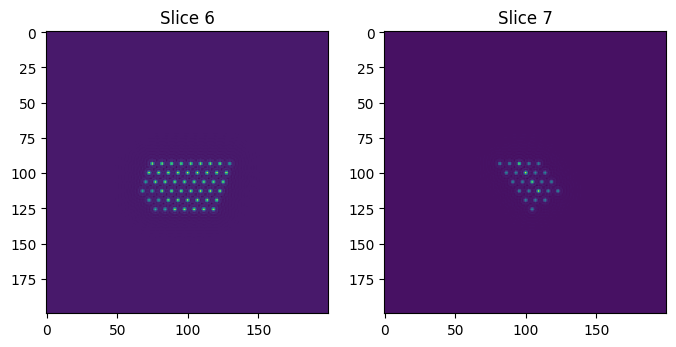

In [114]:
# Display potentials
nx=200
ny=200
slc_1 = np.fromfile('slc/Pt_006.pot', dtype='complex64').reshape((nx, ny))
slc_2 = np.fromfile('slc/Pt_007.pot', dtype='complex64').reshape((nx, ny))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(np.real(slc_1))
axs[1].imshow(np.real(slc_2))
axs[0].set_title('Slice 6')
axs[1].set_title('Slice 7')

In [115]:
# Create Parameter file for multislice


# Initialize constant parameters
ht = 300;                   # High tension is 300 kV
nx = 200; ny = 200; nz = 10        # All images, wavefunctions, etc. will be 512 x 512 pixels
# nz = 155;                 # The structures will be cut into 155 slices
dwf = True; buni = 0.005;   # Debye-Wallar factor on and set B = 0.5 Ang^2
#dwf = True; buni = 0.000;   # Debye-Wallar factor on and set B = 0.5 Ang^2
absorb = True;              # Apply built-in absorptive form factors
output = True;              # Give chatty output during simulations
##Cs = -13000
#Cs = -13000                 # Cs = -9 um, enter in nm
#C5 = 5000000                # C5 = 5 mm, enter in nm
Cs = -9000                 # Cs = -9 um, enter in nm
C5 = 5000000                # C5 = 5 mm, enter in nm
# Initialize general MSA Parameter File
msa = drp.msaprm.MsaPrm()






msa.tot_number_of_slices = 10 # Corresponds to 5 layers / unit cells of SrTiO3

msa.wavelength = 0.0019687482               # Electron wavelength in nm
msa.focus_spread = 4                        # Focus half-spread in nm
msa.tilt_x = 0
msa.tilt_y = 0
msa.h_scan_frame_size = a                   # This is the size of the cel in nm
msa.v_scan_frame_size = b 
msa.scan_columns = nx                       # Unsure if matters but consistent with image
msa.scan_rows = ny  
msa.temp_coherence_flag = 0                 # Turn off temporal coherence calculation (STEM only)
msa.spat_coherence_flag = 0                 # Turn off spatial coherence calculation (STEM only)
msa.slice_files = 'slc/Pt'                        # String of slice file, will be set iteratively later
msa.number_of_slices = nz                   # Load one slice at a time
msa.det_readout_period = 0                  # No detector effects included.
msa.tot_number_of_slices = nz               # Each structure contains nz slices
msa.aberrations_dict = {1: (0, 0),          # Defocus of 0 nm standard, will be adjusted iteratively later
                                5: (Cs, 0),         # Cs = -13 um
                                11: (C5, 0)}        # C5 = 5 mm         
msa.tot_number_of_slices = 10 
msa.save_msa_prm('mod1.prm') # Save the initailized MSA prm file



In [116]:
msa_path = '/home/thiago/drprobe_clt_bin.linux/bin/msa'     # Replace this with the actual full path to the 'msa' executable
prm_file = 'mod1.prm'
output_file = 'wav/Pt.wav'

# The msa command arguments
msa_cmd = [msa_path, '-prm', prm_file, '-out', output_file]

# Execute the msa command using subprocess
subprocess.run(msa_cmd, check=True)


 +---------------------------------------------------+
 | Program: [msa] MultiSlice Algorithm               |
 | Version: 1.0.8 64-bit  -  2020 Aug  12  -         |
 | Author : Dr. J. Barthel, ju.barthel@fz-juelich.de |
 |          Forschungszentrum Juelich GmbH, GERMANY  |
 | License: GNU GPL 3 <http://www.gnu.org/licenses/> |
 +---------------------------------------------------+


Loading parameter file.
Begin of multislice calculations.
Calculating STEM pixel  199,  199          
End of multislice calculations.


CompletedProcess(args=['/home/thiago/drprobe_clt_bin.linux/bin/msa', '-prm', 'mod1.prm', '-out', 'wav/Pt.wav'], returncode=0)

In [149]:
# Create Parameter file for wavimg
wavimg = drp.WavimgPrm()
sl = 6 # Perform simulation for slice # 2

# Setup (fundamental) MSA parameters
wavimg.high_tension = 300
wavimg.mtf = (0, 0, '') 
wavimg.oa_radius = 25 # Apply objective aperture [mrad]
wavimg.vibration = (1, 0.016, 0.016, 0) # Apply isotropic image spread of 16 pm rms displacement
wavimg.spat_coherence = (1, 0.4) # Apply spatial coherence
wavimg.wave_sampling = (a / nx, b / ny)
wavimg.wave_files = 'wav/Pt_sl{:03d}.wav'.format(sl)
wavimg.wave_dim = (nx, ny)

wavimg.aberrations_dict = {1: (1, 0)} # apply defocus of 1 nm

wavimg.output_files = 'img/Pt_sl{:03d}.dat'.format(sl) # Simulate for slice number "sl"
wavimg.output_format = 0
wavimg.flag_spec_frame = 1
wavimg.output_dim = (nx, ny)
wavimg.output_sampling = (a / nx, b / ny)

# Save wavimg Parameter file
wavimg.save_wavimg_prm('wavimg.prm')

In [150]:


wavimg_path = '/home/thiago/drprobe_clt_bin.linux/bin/wavimg'     # Replace this with the actual full path to the 'wavimg' executable
prm_file = 'wavimg.prm'

# The wavimg command arguments
wavimg_cmd = [wavimg_path, '-prm', prm_file]

# Execute the wavimg command using subprocess
subprocess.run(wavimg_cmd, check=True)



 +---------------------------------------------------+
 | Program: [wavimg]                                 |
 | Version: 1.0.2 64-bit  -  2020 Oct  15  -         |
 | Author : Dr. J. Barthel, ju.barthel@fz-juelich.de |
 |          Forschungszentrum Juelich GmbH, GERMANY  |
 | License: GNU GPL 3 <http://www.gnu.org/licenses/> |
 +---------------------------------------------------+

Loading parameters from file [wavimg.prm].
Finished loading parameters.
- internal array size:   256
Parameters checked successfully.
Loading wave function data from file [wav/Pt_sl006.wav].
Creating TEM image from wave.
Image calculation by explicit focal integration.
0-----------------------------------------------------------1
************************************************************* 
Extracting image frame data.
Applying envelopes to image data.
Saving image data to file [img/Pt_sl006.dat].
Data format: 32-bit float
Finished all calculations.
Number of warnings:   0,  number of errors:   0.


CompletedProcess(args=['/home/thiago/drprobe_clt_bin.linux/bin/wavimg', '-prm', 'wavimg.prm'], returncode=0)

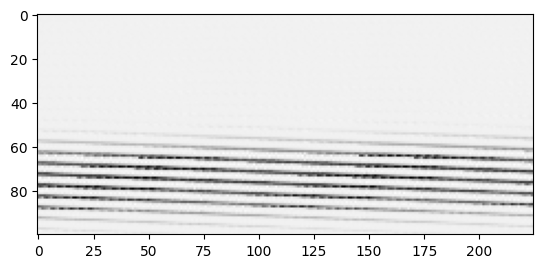

In [151]:
# Display image
img = np.fromfile('img/Pt_sl010.dat', dtype='float32').reshape((100, 225))
plt.imshow(img, cmap='gray')

In [1]:
import sys
print(sys.path)

['/Users/vkolluru/Documents/My Projects/Ceria_Pt nanocrystals/Thiago_on_slack/thiago_notebooks', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python311.zip', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11/lib-dynload', '', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11/site-packages', '/Users/vkolluru/Documents/Github_repos/ingrained', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11/site-packages/imutils-0.5.4-py3.11.egg', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11/site-packages/scikit_image-0.21.0-py3.11-macosx-10.9-x86_64.egg', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11/site-packages/sklearn-0.0.post5-py3.11.egg', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11/site-packages/pyspm-0.3.2-py3.11.egg', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11/site-packages/opencv_python-4.8.0.74-py3.11-macosx-10.9-x86_64.egg', '/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11/

Pt_6_layer.ipynb                        graph_nanocluster_representation.ipynb
Pt_6layer.cel                           stacking_fault.ipynb
Wulff_Pt.ipynb
